# Unsupervised and Supervised Feature Discovery: PCA, DAS, and DBM

In the previous notebooks we used activation patching and the `locate` analysis to find *where* the model encodes a causal variable. Now we go deeper: **what low-dimensional structure does that encoding have?**

This notebook explores three complementary methods for feature discovery:

| Method | Type | What it learns |
|---|---|---|
| **PCA** | Unsupervised | Directions of maximum variance — no causal labels needed |
| **DAS** | Supervised | Subspace that *causally* separates the target variable — PCA-initialized |
| **DBM** | Supervised | Which *specific PCA components* are causally relevant — sparse masks |

The three methods are complementary, not competing:
- PCA finds what the model *does* store (variance structure)
- DAS finds what the model *needs* to store (causal structure)
- DBM finds the sparse overlap between the two (which PCA components matter)

In this notebook we:
1. Run all three methods on the same (layer, token_position) cell and compare them directly
2. Show how to scale to a full grid scan using the `subspace` analysis runner

## 1A. Unsupervised Structure with PCA

Principal Component Analysis (PCA) finds the directions in activation space that capture the most variance across examples. Because we apply no causal labels, this tells us about the *intrinsic geometry* of the model's representations — not just for one variable, but for everything the model has learned to encode at this site.

The question PCA answers: **Does the model's activation space have visible structure that aligns with the causal variable we care about?**

If the answer_position variable (0 = first choice, 1 = second choice) is linearly encoded, PCA will reveal it as a separating direction even without being told about it. That is the unsupervised claim.

In [1]:
# PARAMETERS
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"
MAX_NEW_TOKENS = 1

import torch
from causalab.neural.pipeline import LMPipeline
from causalab.tasks.MCQA.causal_models import positional_causal_model

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = LMPipeline(
    MODEL_NAME,
    max_new_tokens=MAX_NEW_TOKENS,
    device=device,
    dtype=torch.bfloat16 if device == "cuda" else torch.float32,
)
causal_model = positional_causal_model

print("DEVICE:", pipeline.model.device)

Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


DEVICE: cuda:0


In [2]:
# PARAMETERS
DATASET_SIZE = 512   # number of examples for PCA (unfiltered — larger = better PCA)

from causalab.tasks.MCQA.counterfactuals import different_symbol

# Generate an unfiltered dataset for PCA.
# We use different_symbol: both prompts are identical except the answer label changes.
# Unfiltered means we don't require the model to answer correctly — PCA reveals variance
# structure regardless of model accuracy.
dataset = [different_symbol() for _ in range(DATASET_SIZE)]

# Extract labels for scatter plot coloring
labels_answer_position = [ex["input"]["answer_position"] for ex in dataset]
labels_answer = [ex["input"]["answer"] for ex in dataset]

print(f"Dataset size: {len(dataset)}")
print(f"answer_position distribution: {dict((v, labels_answer_position.count(v)) for v in set(labels_answer_position))}")

Dataset size: 512
answer_position distribution: {0: 263, 1: 249}


In [3]:
# PARAMETERS
LAYER = 10          # layer to analyze
N_COMPONENTS = 32   # number of PCA components to compute

from causalab.neural.activations import build_residual_stream_targets
from causalab.tasks.MCQA.token_positions import create_token_positions

# create_token_positions returns a dict of named positions for the MCQA template.
# We use "last_token": the position the model reads when generating its answer.
token_positions_dict = create_token_positions(pipeline)
last_token_pos = token_positions_dict["last_token"]

# Build one InterchangeTarget per (layer, position) cell.
# mode="one_target_per_unit" gives a separate target for each cell — good for PCA.
targets = build_residual_stream_targets(
    pipeline=pipeline,
    layers=[LAYER],
    token_positions=[last_token_pos],
    mode="one_target_per_unit",
)

print(f"Available token positions: {list(token_positions_dict.keys())}")
print(f"Built {len(targets)} target(s):")
for key in targets:
    print(f"  {key}: {len(targets[key].flatten())} unit(s)")

Available token positions: ['correct_symbol', 'correct_symbol_period', 'symbol0', 'symbol0_period', 'symbol1', 'symbol1_period', 'last_token']
Built 1 target(s):
  (10, 'last_token'): 1 unit(s)


In [4]:
from causalab.methods.pca import collect_features, compute_svd

# collect_features takes a flat list of AtomicModelUnit objects.
# We unpack all units from all targets into one list.
all_units = [unit for target in targets.values() for unit in target.flatten()]

print("Collecting activations...")
features_dict = collect_features(
    dataset=dataset,
    pipeline=pipeline,
    model_units=all_units,
    batch_size=32,
)

# compute_svd returns one result dict per unit ID.
# Keys in the result: "rotation" (n_features x n_components), "explained_variance_ratio"
svd_results = compute_svd(features_dict, n_components=N_COMPONENTS)

# Grab the first (and only) unit for inspection
unit_id = list(features_dict.keys())[0]
features = features_dict[unit_id]           # shape: (n_examples, hidden_size)
svd = svd_results[unit_id]

print(f"\nUnit: {unit_id}")
print(f"Features shape: {features.shape}")
print(f"Rotation shape: {svd['rotation'].shape}")

# Explained variance summary
explained_var = svd["explained_variance_ratio"]
print("\nTop 5 PCA components explain:")
for i, var in enumerate(explained_var[:5]):
    print(f"  PC{i}: {var:.1%}")
print(f"  Total (top {N_COMPONENTS}): {sum(explained_var):.1%}")


Unit: ResidualStream(Layer-10,block_output,Token-last_token)
Features shape: torch.Size([512, 2048])
Rotation shape: torch.Size([2048, 32])

Top 5 PCA components explain:
  PC0: 93.5%
  PC1: 1.6%
  PC2: 0.6%
  PC3: 0.5%
  PC4: 0.3%
  Total (top 32): 99.1%


2D PCA scatters — colored by answer_position:


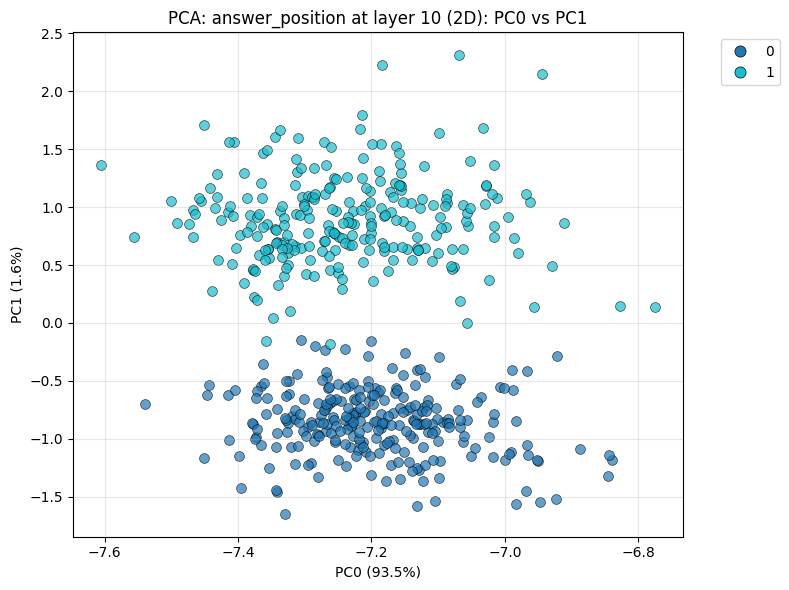

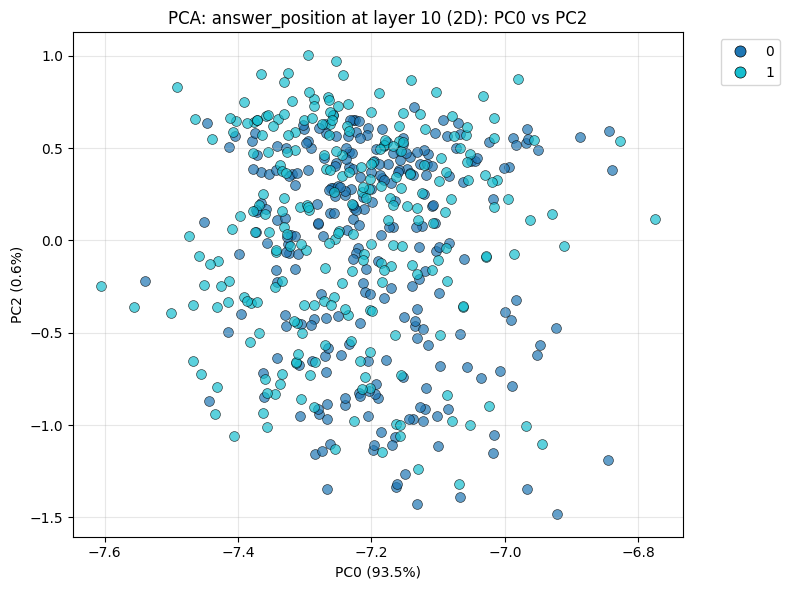

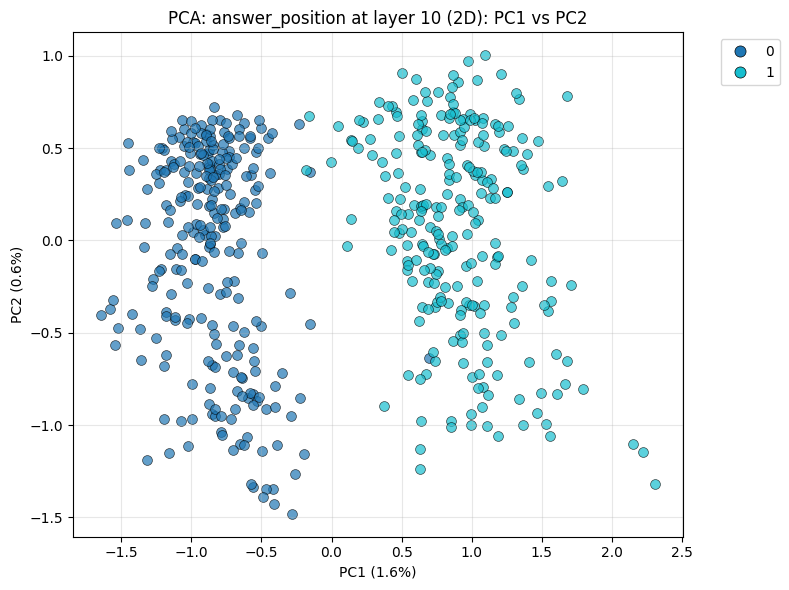

3D PCA scatter — colored by answer_position:


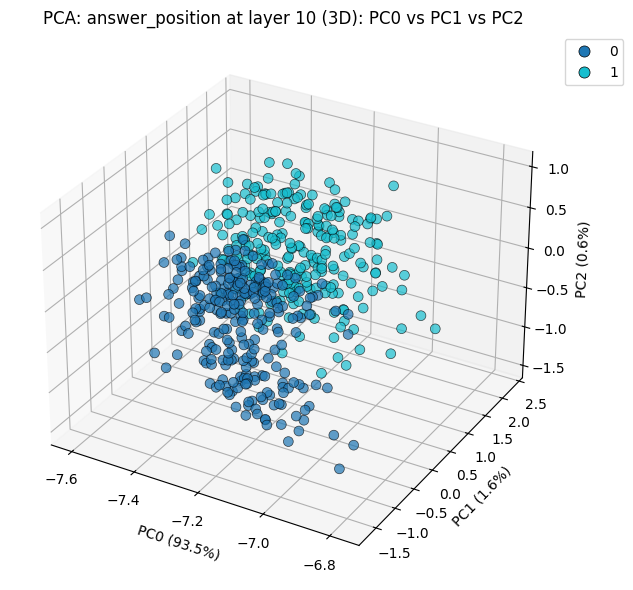

In [5]:
from causalab.io.plots.pca_scatter import plot_pca_scatter

# 2D scatters across multiple component pairs: shows how separability shifts
# when you look beyond the top two PCs. (0,1) is the canonical view; (0,2) and
# (1,2) reveal whether the answer_position signal is concentrated on PC0 or
# distributed across higher components.
print("2D PCA scatters — colored by answer_position:")
plot_pca_scatter(
    features=features,
    svd_result=svd,
    labels=labels_answer_position,
    component_tuples=[(0, 1), (0, 2), (1, 2)],
    title=f"PCA: answer_position at layer {LAYER} (2D)",
    figure_format="png",
)

# 3D scatter: more components, more structure
print("3D PCA scatter — colored by answer_position:")
plot_pca_scatter(
    features=features,
    svd_result=svd,
    labels=labels_answer_position,
    component_tuples=[(0, 1, 2)],
    title=f"PCA: answer_position at layer {LAYER} (3D)",
    figure_format="png",
)


2D PCA scatter — color=answer letter, shape=answer_position:


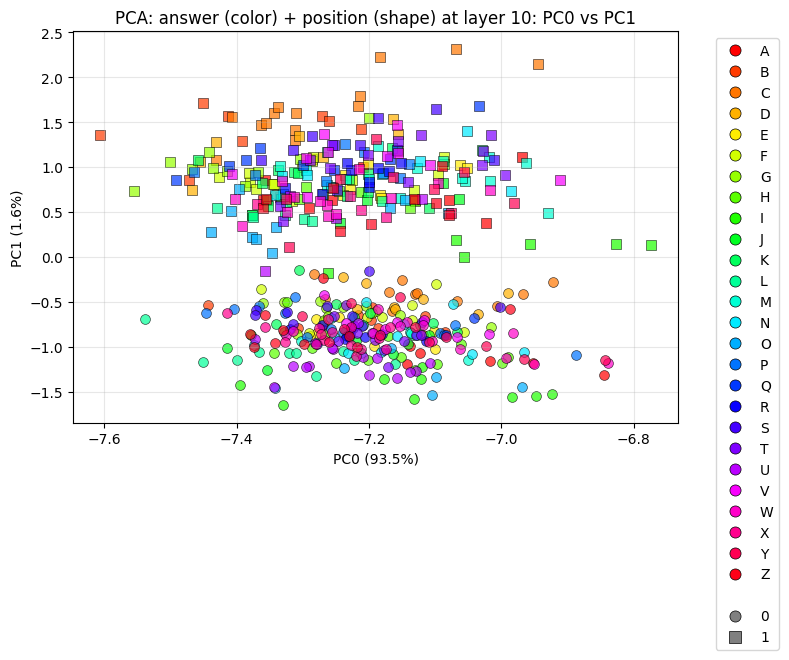

3D PCA scatter — color=answer letter, shape=answer_position:


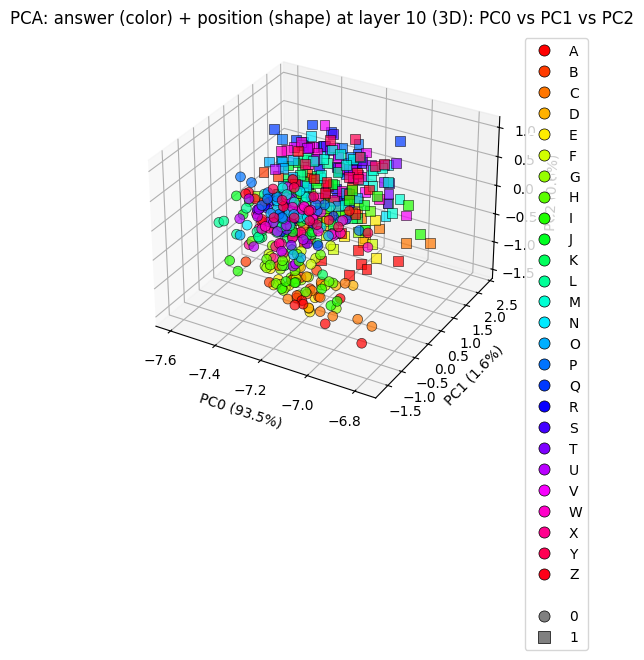

In [6]:
# Dual-label: color by answer letter, shape by answer_position.
# This reveals two variables at once — if PCA has separated both, the scatter
# will show organized color blocks AND shape clusters.
print("2D PCA scatter — color=answer letter, shape=answer_position:")
plot_pca_scatter(
    features=features,
    svd_result=svd,
    labels=labels_answer,
    shape_labels=labels_answer_position,
    component_tuples=[(0, 1)],
    title=f"PCA: answer (color) + position (shape) at layer {LAYER}",
    figure_format="png",
)

print("3D PCA scatter — color=answer letter, shape=answer_position:")
plot_pca_scatter(
    features=features,
    svd_result=svd,
    labels=labels_answer,
    shape_labels=labels_answer_position,
    component_tuples=[(0, 1, 2)],
    title=f"PCA: answer (color) + position (shape) at layer {LAYER} (3D)",
    figure_format="png",
)


**What to look for in the PCA scatter:**

- **Clean separation by color** — two distinct clusters colored by answer_position — means the variable is linearly encoded. The first principal component aligns with this signal.
- **Mixed colors, no separation** — the variable is either nonlinearly encoded or encoded elsewhere in the model.
- **Variance explained** — if the top 5 components explain >50% of variance, the activation space is quite low-dimensional here. That is a good sign for both DAS and DBM.

The dual-label plot (color=answer, shape=position) shows if PCA is simultaneously capturing both the answer letter and its position. These are two separate causal variables encoded at the same site.

## 1A.2 Comparing layers in a shared PCA space

So far we ran PCA on a single layer. **Stack mode** concatenates activations from multiple layers into one feature matrix, then runs SVD on the union. The resulting principal components are shared across layers, so the scatter directly compares where each layer sits in a single coordinate system — useful for asking *how does the representation change with depth?*

Stack mode is currently exposed only via `collect_and_compute_PCA` in `causalab.methods.pca` (the new `collect_features` + `compute_svd` split is per-unit). We use it here purely for in-memory exploration; nothing is written to disk.


In [7]:
from causalab.methods.pca import collect_and_compute_PCA

STACK_LAYERS = [0, 5, 10, 15]   # layers to compare in shared PCA space

stacked_targets = build_residual_stream_targets(
    pipeline=pipeline,
    layers=STACK_LAYERS,
    token_positions=[last_token_pos],
    mode="one_target_all_units",   # bundles all (layer, position) pairs into one target
)

# stack mode concatenates units along the sample axis before SVD; in-memory only,
# the function does not write to disk.
stacked_result = collect_and_compute_PCA(
    interchange_targets=stacked_targets,
    data=dataset,
    pipeline=pipeline,
    labels=labels_answer_position,
    component_tuples=[(0, 1)],
    combine_mode="stack",
    n_components=10,
    verbose=False,
)

# Result keys are joined unit-id strings; grab the only target.
stacked_key = list(stacked_result["features_by_target"].keys())[0]
stacked_features = stacked_result["features_by_target"][stacked_key]
stacked_svd = stacked_result["svd_results_by_target"][stacked_key]

# One label per layer; plot_pca_scatter auto-replicates to match the stacked sample count.
stacked_units = list(stacked_targets.values())[0].flatten()
unit_labels = [f"Layer {u.layer}" for u in stacked_units]

print(f"Stacked feature matrix: {tuple(stacked_features.shape)}")
print(f"{len(unit_labels)} layer labels (auto-replicated to {stacked_features.shape[0]} samples)")


Stacked feature matrix: (2048, 2048)
4 layer labels (auto-replicated to 2048 samples)


Stack mode — colored by layer:


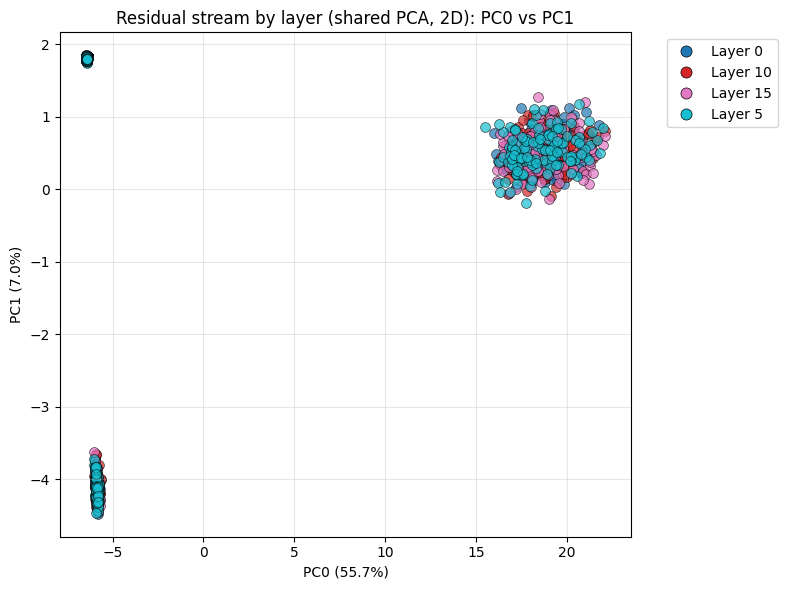

In [8]:
# 2D stack scatter colored by layer — shows where each layer sits in shared PCA space.
print("Stack mode — colored by layer:")
plot_pca_scatter(
    features=stacked_features,
    svd_result=stacked_svd,
    labels=unit_labels,
    component_tuples=[(0, 1)],
    title="Residual stream by layer (shared PCA, 2D)",
    figure_format="png",
)


Stack mode — color=layer, shape=answer_position:


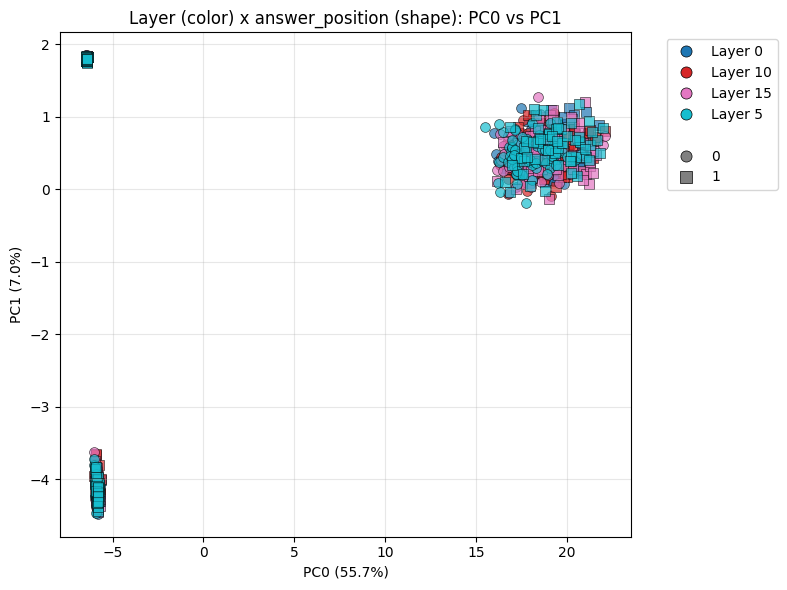

In [9]:
# Dual-label: color=layer, shape=answer_position.
# Reveals whether each layer separately encodes answer_position within the shared basis.
print("Stack mode — color=layer, shape=answer_position:")
plot_pca_scatter(
    features=stacked_features,
    svd_result=stacked_svd,
    labels=unit_labels,
    shape_labels=labels_answer_position,
    component_tuples=[(0, 1)],
    title="Layer (color) x answer_position (shape)",
    figure_format="png",
)


## 1B. Causal Refinement with DAS

PCA finds directions of maximum variance — but variance is not the same as causal relevance. Consider: the model might store the answer letter and its position at this layer, plus residual noise from earlier computations. PCA will explain all of it.

**Distributed Alignment Search (DAS)** adds a causal filter: it searches for a low-dimensional subspace where *interchange interventions* reliably flip the model's output when we swap activations between two examples that differ on the target variable. The subspace must be causally active, not just statistically prominent.

By initializing DAS from the PCA rotation matrix, we give it a structured starting point. DAS then fine-tunes the basis to maximize intervention success — often only a small rotation away from PCA.

**Key questions:**
1. Does the DAS scatter look noticeably tighter than PCA?
2. Are train and test scores similar? (Large gap = overfitting)
3. How many epochs to converge?

In [10]:
# PARAMETERS
TRAIN_SIZE = 128   # examples for DAS/DBM training and testing
TEST_SIZE  = 64
K_FEATURES = 2    # subspace dimensionality for DAS (and DBM comparison)

from causalab.tasks.MCQA.counterfactuals import same_symbol_different_position
from causalab.methods.filter import filter_dataset

# DAS/DBM require filtered datasets: both the base and counterfactual prompt must be
# answered correctly by the model. This ensures we study model computation, not errors.
# same_symbol_different_position varies answer_position while keeping the answer letter.
def checker(neural_output, causal_output):
    return (
        causal_output.strip() in neural_output["string"].strip()
        or neural_output["string"].strip() in causal_output.strip()
    )

raw_train = [same_symbol_different_position() for _ in range(TRAIN_SIZE * 3)]
raw_test  = [same_symbol_different_position() for _ in range(TEST_SIZE  * 3)]

train_dataset = filter_dataset(raw_train, pipeline, causal_model, checker)
test_dataset  = filter_dataset(raw_test,  pipeline, causal_model, checker)

# Take a fixed-size split after filtering
train_dataset = train_dataset[:TRAIN_SIZE]
test_dataset  = test_dataset[:TEST_SIZE]

print(f"Training examples: {len(train_dataset)} (filtered from {len(raw_train)})")
print(f"Test examples:     {len(test_dataset)} (filtered from {len(raw_test)})")

Training examples: 128 (filtered from 384)
Test examples:     64 (filtered from 192)


In [11]:
from causalab.methods.trained_subspace.subspace import SubspaceFeaturizer

# Initialize each unit's featurizer from the PCA rotation matrix.
# - rotation_subspace: first K_FEATURES principal components (hidden_size x K_FEATURES)
# - trainable=True: DAS will refine these directions during training
# - id != 'null': train_interventions will skip re-initializing this featurizer

# Re-build targets for the DAS run (fresh units, no residual featurizer state)
targets_das = build_residual_stream_targets(
    pipeline=pipeline,
    layers=[LAYER],
    token_positions=[last_token_pos],
    mode="one_target_per_unit",
)

for target in targets_das.values():
    for unit in target.flatten():
        rotation = svd_results[unit.id]["rotation"]  # shape: (hidden_size, N_COMPONENTS)
        featurizer = SubspaceFeaturizer(
            rotation_subspace=rotation[:, :K_FEATURES],
            trainable=True,
            id="PCA_init",
        )
        unit.set_featurizer(featurizer)

print(f"Initialized targets with PCA rotation (first {K_FEATURES} components, trainable=True)")

Initialized targets with PCA rotation (first 2 components, trainable=True)


In [12]:
# PARAMETERS
DAS_EPOCHS = 4
DAS_LR     = 0.001
BATCH_SIZE = 32

import os
import causalab
from causalab.methods.trained_subspace.train import train_interventions
from causalab.configs.train_config import merge_with_defaults

# Per docs/CODEBASE.md invariant 7, all artifacts live under artifacts/.
project_root = os.path.dirname(os.path.dirname(causalab.__file__))
das_log_dir = os.path.join(project_root, "artifacts", "demo_logs", "das")

das_config = merge_with_defaults({
    "intervention_type": "interchange",  # DAS uses subspace interchange
    "DAS": {"n_features": K_FEATURES},
    "train_batch_size": BATCH_SIZE,
    "evaluation_batch_size": BATCH_SIZE,
    "training_epoch": DAS_EPOCHS,
    "init_lr": DAS_LR,
    "log_dir": das_log_dir,
})

das_result = train_interventions(
    causal_model=causal_model,
    interchange_targets=targets_das,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    pipeline=pipeline,
    target_variable_group=("answer_position",),
    metric=checker,
    config=das_config,
)

print(f"DAS avg train score: {das_result['avg_train_score']:.3f}")
print(f"DAS avg test  score: {das_result['avg_test_score']:.3f}")


DAS avg train score: 0.906
DAS avg test  score: 0.891


In [13]:
# Project the PCA features into both the original PCA space and the DAS-refined space
# to compare them side by side.

# DAS-refined rotation: extract from the trained featurizer.
# The SubspaceFeaturizer stores the rotation in .featurizer.rotate.weight
unit = list(targets_das.values())[0].flatten()[0]
das_rotation = unit.featurizer.featurizer.rotate.weight.data.detach().cpu().float()  # shape: (hidden_size, K_FEATURES)

# Cast to float32 — features may be bfloat16, which numpy can't handle
features_f32 = features.float().cpu()

# Project both with the full PCA feature set for consistency
pca_features_2d = features_f32 @ svd_results[unit_id]["rotation"][:, :K_FEATURES].float()
das_features_2d = features_f32 @ das_rotation

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["tab:blue" if l == 0 else "tab:orange" for l in labels_answer_position]

axes[0].scatter(pca_features_2d[:, 0], pca_features_2d[:, 1], c=colors, alpha=0.4, s=10)
axes[0].set_title(f"PCA projection (layer {LAYER})")
axes[0].set_xlabel("PC0")
axes[0].set_ylabel("PC1")

axes[1].scatter(das_features_2d[:, 0], das_features_2d[:, 1], c=colors, alpha=0.4, s=10)
axes[1].set_title(f"DAS projection (PCA-initialized, layer {LAYER})")
axes[1].set_xlabel("DAS dim 0")
axes[1].set_ylabel("DAS dim 1")

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=f"pos={l}")
           for l, c in [(0, 'tab:blue'), (1, 'tab:orange')]]
axes[1].legend(handles=handles)

plt.tight_layout()
plt.show()

**Interpreting the DAS comparison:**

- **Tighter clusters in DAS** means causal supervision improved linear separability. The DAS objective explicitly optimizes for clean interchange, which requires the two classes to be linearly separable.
- **Similar PCA and DAS scatter** means PCA was already capturing the causal structure — the unsupervised method was sufficient.
- **DAS train >> DAS test** indicates overfitting (too few training examples or too many epochs). Reduce `DAS_EPOCHS` or increase `TRAIN_SIZE`.
- **Low DAS test score** at this layer means the variable is not well-encoded here. Try a different `LAYER` (the `locate` analysis gives the best guess).

## 1C. Sparse Feature Selection with DBM

DAS refines *all* PCA directions. But maybe only a handful of them matter. **DBM (Desiderata-Based Masking)** answers this by keeping the PCA basis *fixed* and learning binary masks over its components. A mask of 1 means that component participates in the intervention; a mask of 0 means it is ignored.

With PCA-initialized DBM (`trainable=False`):
- Standard DBM masks raw activation dimensions (e.g., 2048 dims — very high-dimensional)
- **PCA-initialized DBM** masks principal components — a much smaller and more interpretable set

The key question: **How many principal components are actually causally necessary?**

In [14]:
# DBM operates on a *single* target that contains all units together.
# mode="one_target_all_units" bundles all (layer, position) pairs into one target
# so DBM can learn a joint mask across all of them.
# Here we analyze a small set of layers to keep the run fast.

# PARAMETERS
DBM_LAYERS = [0, 5, 10, 15]   # layers to include in the DBM target

targets_dbm = build_residual_stream_targets(
    pipeline=pipeline,
    layers=DBM_LAYERS,
    token_positions=[last_token_pos],
    mode="one_target_all_units",
)

print(f"Built DBM target with {sum(len(t.flatten()) for t in targets_dbm.values())} units total:")
for key, target in targets_dbm.items():
    print(f"  {key}: {len(target.flatten())} units")
    for unit in target.flatten():
        print(f"    - {unit.id}")

Built DBM target with 4 units total:
  ('all',): 4 units
    - ResidualStream(Layer-0,block_output,Token-last_token)
    - ResidualStream(Layer-5,block_output,Token-last_token)
    - ResidualStream(Layer-10,block_output,Token-last_token)
    - ResidualStream(Layer-15,block_output,Token-last_token)


In [15]:
# We need SVD results for each of the DBM layers.
# First collect features for all DBM layers, then compute SVD.

targets_dbm_all_pca = build_residual_stream_targets(
    pipeline=pipeline,
    layers=DBM_LAYERS,
    token_positions=[last_token_pos],
    mode="one_target_per_unit",   # per-unit for PCA
)
all_units_dbm = [unit for target in targets_dbm_all_pca.values() for unit in target.flatten()]

print("Collecting activations for DBM layers...")
features_dict_dbm = collect_features(
    dataset=dataset,
    pipeline=pipeline,
    model_units=all_units_dbm,
    batch_size=32,
)
svd_results_dbm = compute_svd(features_dict_dbm, n_components=N_COMPONENTS)

print(f"SVD computed for units: {list(svd_results_dbm.keys())}")

SVD computed for units: ['ResidualStream(Layer-0,block_output,Token-last_token)', 'ResidualStream(Layer-5,block_output,Token-last_token)', 'ResidualStream(Layer-10,block_output,Token-last_token)', 'ResidualStream(Layer-15,block_output,Token-last_token)']


In [16]:
# Initialize each unit in the DBM target with the full PCA basis (trainable=False).
# DBM will learn which components to mask — not change the directions themselves.

for target in targets_dbm.values():
    for unit in target.flatten():
        rotation = svd_results_dbm[unit.id]["rotation"]  # full rotation matrix
        featurizer = SubspaceFeaturizer(
            rotation_subspace=rotation,    # full PCA basis — all components
            trainable=False,               # fixed PCA directions; DBM learns masks only
            id="PCA_for_DBM",
        )
        unit.set_featurizer(featurizer)
        print(f"  {unit.id}: initialized with {rotation.shape[1]} PCA components (fixed)")

print("\nDBM featurizers initialized — basis is fixed, only masks will be learned.")

  ResidualStream(Layer-0,block_output,Token-last_token): initialized with 32 PCA components (fixed)
  ResidualStream(Layer-5,block_output,Token-last_token): initialized with 32 PCA components (fixed)
  ResidualStream(Layer-10,block_output,Token-last_token): initialized with 32 PCA components (fixed)
  ResidualStream(Layer-15,block_output,Token-last_token): initialized with 32 PCA components (fixed)

DBM featurizers initialized — basis is fixed, only masks will be learned.


In [17]:
# PARAMETERS
DBM_EPOCHS = 4
DBM_LR     = 0.001
DBM_LAMBDA = 0.1    # L1 regularization coefficient — higher = sparser selection

dbm_log_dir = os.path.join(project_root, "artifacts", "demo_logs", "dbm")

dbm_config = merge_with_defaults({
    "intervention_type": "mask",     # DBM uses binary feature masks
    "train_batch_size": BATCH_SIZE,
    "evaluation_batch_size": BATCH_SIZE,
    "training_epoch": DBM_EPOCHS,
    "init_lr": DBM_LR,
    "featurizer_kwargs": {"tie_masks": False},  # separate mask per feature dimension
    "masking": {
        "regularization_coefficient": DBM_LAMBDA,
        "temperature_annealing_fraction": 0.5,
    },
    "log_dir": dbm_log_dir,
})

dbm_result = train_interventions(
    causal_model=causal_model,
    interchange_targets=targets_dbm,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    pipeline=pipeline,
    target_variable_group=("answer_position",),
    metric=checker,
    config=dbm_config,
)

print(f"DBM avg train score: {dbm_result['avg_train_score']:.3f}")
print(f"DBM avg test  score: {dbm_result['avg_test_score']:.3f}")


DBM avg train score: 0.609
DBM avg test  score: 0.578


In [18]:
# Extract which PCA components were selected by DBM at each unit
print("Selected PCA components by unit:")
print("=" * 60)

for key, unit_results in dbm_result["results_by_key"].items():
    feature_indices = unit_results.get("feature_indices", {})
    for unit_id_str, indices in feature_indices.items():
        if unit_id_str in svd_results_dbm:
            ev = svd_results_dbm[unit_id_str]["explained_variance_ratio"]
            selected_var = sum(ev[i] for i in indices) if indices else 0.0
            print(f"\n{unit_id_str}:")
            print(f"  Selected components ({len(indices)} of {len(ev)}): {sorted(indices)}")
            print(f"  Variance explained by selected: {selected_var:.1%}")
        elif indices:
            print(f"\n{unit_id_str}: selected indices = {sorted(indices)}")

Selected PCA components by unit:

ResidualStream(Layer-0,block_output,Token-last_token):
  Selected components (0 of 32): []
  Variance explained by selected: 0.0%

ResidualStream(Layer-5,block_output,Token-last_token):
  Selected components (8 of 32): [1, 2, 3, 4, 6, 7, 9, 11]
  Variance explained by selected: 1.3%

ResidualStream(Layer-10,block_output,Token-last_token):
  Selected components (20 of 32): [0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 12, 14, 15, 18, 19, 20, 21, 23, 25, 27]
  Variance explained by selected: 98.1%

ResidualStream(Layer-15,block_output,Token-last_token):
  Selected components (1 of 32): [0]
  Variance explained by selected: 90.2%


In [19]:
# Visualize which PCA components DBM selected at each unit.
# Rows = units (layers), columns = PCA component index, white = selected.
import matplotlib.pyplot as plt
import numpy as np

unit_ids = sorted(svd_results_dbm.keys())
selection_matrix = np.zeros((len(unit_ids), N_COMPONENTS))

# results_by_key has a single entry for the one DBM target.
unit_results = next(iter(dbm_result["results_by_key"].values()))
feature_indices = unit_results.get("feature_indices", {})
for row, uid in enumerate(unit_ids):
    for c in feature_indices.get(uid, []):
        if c < N_COMPONENTS:
            selection_matrix[row, c] = 1.0

fig, ax = plt.subplots(figsize=(12, max(2.0, 0.45 * len(unit_ids) + 1.0)))
ax.imshow(selection_matrix, aspect="auto", cmap="Greys", vmin=0, vmax=1, interpolation="nearest")
ax.set_yticks(range(len(unit_ids)))
ax.set_yticklabels(unit_ids, fontsize=8)
ax.set_xticks(range(0, N_COMPONENTS, max(1, N_COMPONENTS // 16)))
ax.set_xlabel("PCA component index")
ax.set_title(f"DBM-selected PCA components per unit (λ={DBM_LAMBDA})")
plt.tight_layout()
plt.show()


**Interpreting the DBM component selection:**

- **Few components selected (1–4)** — sparse, interpretable encoding. The variable lives in a very small subspace of the PCA basis.
- **Many components selected (>10)** — diffuse encoding. The variable is distributed across many directions. DBM may struggle to generalize (check test score).
- **All components selected** — the regularization coefficient (`DBM_LAMBDA`) is too small. Increase it to push DBM toward sparser solutions.
- **No components selected** — the variable is not encoded at this (layer, position). DBM correctly abstains by setting all masks to zero.

## What to look for: comparing all three methods

Running PCA, DAS, and DBM on the same (layer, token_position) cell reveals how the three perspectives relate:

| What you observe | What it means |
|---|---|
| PCA and DAS scatter are nearly identical | PCA already found the causal subspace — variance = causal signal at this site |
| DAS is cleaner than PCA | Unsupervised variance mixes causal and non-causal structure; supervision helps |
| DBM selects exactly 1–2 PCA components | Elegant: one PCA direction carries all the causal information |
| DBM selects many components | Encoding is distributed; DBM masks are less interpretable |
| All scores are low | Wrong layer — use `locate` to find the right (layer, position) first |

**Good results to move forward:**
- PCA shows visible clustering by answer_position
- DAS test score > 0.6 (chance is 0.5 for binary)
- DBM selects a small, consistent set of components across runs

Try changing `LAYER` to explore how the encoding evolves across the network. Layers near the input embed raw token identity; layers near the output carry more processed, task-relevant structure.

---

## From exploration to analysis

The exploration above operates at a single (layer, token_position) cell. A research question lives at the level of populations: **across all inputs and all layers, which cells and which subspace dimensions most reliably encode the causal variable?** Answering that requires:

- Repeating the experiment over many (layer, token_position) cells to build a score heatmap
- Running with a versioned, reproducible configuration
- Saving artifacts for downstream analyses (`activation_manifold`, `path_steering`)

This is exactly what the **`subspace` analysis** does. Under the hood it calls the same `compute_svd`, `SubspaceFeaturizer`, and `train_interventions` you just wrote — packaged behind a Hydra config that becomes the single source of truth for every parameter. The rest of this notebook shows how to define that config and run the full analysis end-to-end.

## Running the `subspace` analysis end-to-end

The config below runs PCA across a grid of layers and token positions. Edit any field and re-run the cell to update the config file.

| Field | What it controls |
|---|---|
| `method` | `pca` (unsupervised), `das`, or `dbm` — matches what you just ran in Section 1 |
| `k_features` | Number of subspace dimensions (was `N_COMPONENTS` / `K_FEATURES` above) |
| `layers` | List of layers to scan; `null` = auto-resolve from `locate/` results |
| `token_positions` | List of token position names; `null` = all task positions |
| `n_train` / `n_test` | Dataset sizes for supervised methods (DAS/DBM) |
| `enumerate_all` | Use every possible input combination rather than sampling |
| `das.training_epoch` / `das.lr` | DAS training hyperparameters (was `DAS_EPOCHS` / `DAS_LR` above) |
| `visualization.figure_format` | `png` (notebook) or `pdf` (publication) |

We use `method: pca` here — unsupervised, no overfitting risk, deterministic. Section 1 demonstrated that DAS and DBM refine PCA on this same grid; use `method: das` or `method: dbm` once you have identified the right (layer, position) and want the full supervised analysis.

In [ ]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: MCQA
  - /model: llama32_1b_instruct
  - /analysis/subspace
  - _self_
task:
  target_variable: answer_position
  n_train: 512
  n_test: 50
  enumerate_all: true

subspace:
  method: pca
  k_features: 32
  layers: [0, 5, 10, 15]
  visualization:
    figure_format: png
"""

In [21]:
from omegaconf import OmegaConf
from causalab.io.configs import save_runner_config, load_runner_config

path = save_runner_config(config_yaml, "05_PCA_DBM_DAS_demo")
print(f"Written to {path}\n")

cfg = load_runner_config("05_PCA_DBM_DAS_demo")
print("Full hydra config:")
print(OmegaConf.to_yaml(cfg))

Written to causalab/configs/05_PCA_DBM_DAS_demo.yaml

Full hydra config:
seed: 42
experiment_root: artifacts/${task.name}/${model.id}
slurm:
  time: 04:00:00
task:
  name: MCQA
  intervention_metric: string_match
  max_new_tokens: 1
  colormap: viridis
  n_train: 512
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variable: answer_position
model:
  id: llama32_1b_instruct
  name: meta-llama/Llama-3.2-1B-Instruct
  device: auto
  dtype: bfloat16
  slurm:
    gpus: 1
subspace:
  _name_: subspace
  _subdir: ${.method}_k${.k_features}
  _output_dir: ${experiment_root}/subspace/${._subdir}
  method: pca
  k_features: 32
  batch_size: 32
  component_type: residual_stream
  layers:
  - 0
  - 5
  - 10
  - 15
  token_positions:
  - last_token
  heads: null
  token_position: null
  modes: null
  visualization:
    figure_format: png
    colormap: ${task.colormap}
    vis_dims: null
    detailed_hover: false
    max_hover_chars: 50
  das:
    training_epoch:

Run the analysis via `scripts/run_exp.sh`. This is the same entry point used from the command line.

In [22]:
import os
import subprocess
import causalab

project_root = os.path.dirname(os.path.dirname(causalab.__file__))

rc = subprocess.run(
    ["bash", "scripts/run_exp.sh", "05_PCA_DBM_DAS_demo"],
    cwd=project_root,
)
if rc.returncode != 0:
    raise Exception(f"Experiment failed with return code {rc.returncode}")

[2026-05-05 14:22:36,141][__main__][INFO] - === Step: subspace (subspace) ===
[2026-05-05 14:22:44,823][__main__][INFO] - Running analysis: subspace | target_variable: answer_position
[2026-05-05 14:22:44,826][__main__][INFO] - Resolved config:
seed: 42
experiment_root: artifacts/${task.name}/${model.id}
slurm:
  time: 04:00:00
task:
  name: MCQA
  intervention_metric: string_match
  max_new_tokens: 1
  colormap: viridis
  n_train: 512
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variable: answer_position
model:
  id: llama32_1b_instruct
  name: meta-llama/Llama-3.2-1B-Instruct
  device: auto
  dtype: bfloat16
  slurm:
    gpus: 1
subspace:
  _name_: subspace
  _subdir: ${.method}_k${.k_features}
  _output_dir: ${experiment_root}/subspace/${._subdir}
  method: pca
  k_features: 32
  batch_size: 32
  component_type: residual_stream
  layers:
  - 0
  - 5
  - 10
  - 15
  token_positions:
  - last_token
  heads: null
  token_position: null
  modes:

Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


[2026-05-05 14:22:46,074][huggingface_hub.file_download][ERROR] - Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


[2026-05-05 14:22:49,480][causalab.analyses.subspace.grid][INFO] - PCA grid complete. Best cell=(0, 'last_token') (0.952)
[2026-05-05 14:22:49,655][causalab.analyses.subspace.main][INFO] - Grid best cell: (layer=0, position=last_token) score=0.9525
[2026-05-05 14:22:49,773][causalab.methods.spline.builders][INFO] - Computed 2 centroids from 512 samples (params: ['answer_position'])
[2026-05-05 14:22:50,850][causalab.io.plots.plot_3d_interactive][INFO] - Saved artifacts/MCQA/llama32_1b_instruct/subspace/pca_k32/answer_position/layer_x_pos/L0_last_token/visualization/features_3d.html
[2026-05-05 14:22:50,850][causalab.analyses.subspace._visualization][INFO] - Saved features_3d.html to artifacts/MCQA/llama32_1b_instruct/subspace/pca_k32/answer_position/layer_x_pos/L0_last_token/visualization
[2026-05-05 14:22:50,859][causalab.methods.spline.builders][INFO] - Computed 2 centroids from 512 samples (params: ['answer_position'])
[2026-05-05 14:22:50,989][causalab.io.plots.pca_scatter][INFO] -

## Artifacts

All outputs land in `artifacts/{task}/{model}/subspace/{method}_k{k_features}/`.

In [23]:
import json

# Derive the artifact directory from the resolved config — never hardcode paths.
analysis_cfg = cfg.subspace
artifact_dir = os.path.join(
    project_root,
    cfg.experiment_root,
    "subspace",
    f"{analysis_cfg.method}_k{analysis_cfg.k_features}",
)
print(f"Artifact directory: {artifact_dir}\n")
print("Contents:", sorted(os.listdir(artifact_dir)))

Artifact directory: artifacts/MCQA/llama32_1b_instruct/subspace/pca_k32

Contents: ['answer_position']


### Grid heatmap

The heatmap shows how much variance each (layer, token_position) cell can capture in a k-dimensional PCA subspace. Darker cells indicate higher explained variance — the model encodes more structure there.

This is the population-level view of what we explored manually in Section 1: across all MCQA inputs, which sites in the model encode the most information? The cell with the highest score is recorded in `grid_results.json` as the best cell for downstream analyses.

**Compare to Section 1:** The best-scoring cell should match (or be near) the `LAYER` you analyzed manually. If it doesn't, that is informative — the single-cell exploration may have been at a sub-optimal location.

In [24]:
from glob import glob
from IPython.display import Image, display

heatmaps_dir = os.path.join(artifact_dir, "heatmaps")
if os.path.isdir(heatmaps_dir):
    matches = glob(os.path.join(heatmaps_dir, "test*.png"))
    if matches:
        display(Image(filename=matches[0]))

grid_path = os.path.join(artifact_dir, "grid_results.json")
if os.path.exists(grid_path):
    with open(grid_path) as f:
        grid_data = json.load(f)
    best = grid_data.get("best_cell", {})
    print(f"Best cell: layer={best.get('layer')}, position={best.get('token_position')}")

    scores = grid_data.get("scores_per_cell", {})
    if scores:
        sorted_cells = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]
        print("\nTop 5 cells by explained variance:")
        for cell_key, score in sorted_cells:
            print(f"  {cell_key}: {score:.3f}")

### Feature scatter at best cell

The scatter plot shows training examples projected into the best-cell PCA subspace, colored by intervention variable. Clean separation confirms that PCA discovered the variable's structure at the population level.

**The `compute_svd` and `plot_pca_scatter` calls you ran in Section 1 are exactly what produced this artifact.** The analysis saved them to disk and regenerated the scatter; loading and displaying it here is identical to the manual `plot_pca_scatter` call you made above.

In [25]:
if os.path.exists(grid_path):
    best_layer = best.get("layer")
    best_pos   = best.get("token_position")

    if best_layer is not None and best_pos is not None:
        scatter_dir = os.path.join(
            artifact_dir, "layer_x_pos",
            f"L{best_layer}_{best_pos}", "visualization",
        )
        if os.path.isdir(scatter_dir):
            matches_2d = glob(os.path.join(scatter_dir, "features_2d*.png"))
            if matches_2d:
                print(f"2D scatter at best cell (layer={best_layer}, pos={best_pos}):")
                display(Image(filename=matches_2d[0]))
        else:
            # Fall back to layer_x_pos root
            scatter_dir = os.path.join(
                artifact_dir, "layer_x_pos", f"L{best_layer}_{best_pos}"
            )
            matches_2d = glob(os.path.join(scatter_dir, "**", "features_2d*.png"), recursive=True)
            if matches_2d:
                display(Image(filename=matches_2d[0]))

## Takeaway

This notebook demonstrated the three-method hierarchy for feature discovery:

1. **PCA** is the natural starting point. It is fast, unsupervised, and reveals whether the variable's structure is linearly accessible at a given site. The grid scan extends this to all layers simultaneously, producing a heatmap of explained variance that identifies the best (layer, token_position).

2. **DAS** refines PCA by adding causal supervision. If the DAS scatter is meaningfully cleaner than PCA, unsupervised variance is mixing causal and non-causal structure. If they look similar, PCA was already sufficient — a sign of clean, well-localized encoding.

3. **DBM** asks the sparsity question: how many PCA directions are causally necessary? Few selected components = sparse, interpretable encoding. This informs downstream geometry analysis (`activation_manifold`) and steering (`path_steering`).

**When to move on:**
- The grid heatmap shows a clear localized peak (not uniform noise across layers)
- PCA scatter at the best cell shows visible separation by the target variable
- If running DAS/DBM: train/test scores are close (no large overfitting gap)

**What comes next:**
- `activation_manifold` — fit geometric models to the discovered subspace (ellipsoids, torii, etc.)
- `path_steering` — test whether the subspace faithfully preserves causal structure under interventions
- `pullback` — optimize geodesic paths through belief space

For the full `subspace` analysis walkthrough including single-cell mode, DAS/DBM variants, and per-component selection: see `causalab/analyses/subspace/demo.ipynb`.